In [8]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
import warnings
warnings.filterwarnings('ignore')

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception("Query failed")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df_fx = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df_fx['date'] = pd.to_datetime(df_fx['date'])
df_fx = df_fx.set_index('date').sort_index()

# Load previous results for comparison
with open('chronos_results.json', 'r') as f:
    chronos_results = json.load(f)

print(f"FX data: {len(df_fx)} days")

FX data: 281 days


In [9]:
ag_dataframes = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    series = df_fx[col].dropna()
    
    ag_df = pd.DataFrame({
        'item_id': col,
        'timestamp': series.index,
        'target': series.values
    })
    
    ag_dataframes[col] = ag_df
    print(f"{col.upper()}: {len(ag_df)} rows")

USD_INR: 281 rows
USD_EUR: 281 rows
USD_GBP: 281 rows
USD_MXN: 280 rows
USD_PHP: 280 rows


In [10]:
TEST_DAYS = 30
TIME_LIMIT_PER_PAIR = 300  # 5 minutes per pair = 25 min total

print(f"Running AutoGluon multi-step ({TEST_DAYS}-day) evaluation on all 5 pairs")
print(f"Time budget: {TIME_LIMIT_PER_PAIR}s per pair = {TIME_LIMIT_PER_PAIR*5/60:.0f} min total\n")

autogluon_evaluation = {}
autogluon_leaderboards = {}
autogluon_best_models = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"\n{col.upper()}...")
    start_time = time.time()
    
    full_df = ag_dataframes[col]
    train_df = full_df.iloc[:-TEST_DAYS]
    test_df = full_df.iloc[-TEST_DAYS:]
    
    train_ts = TimeSeriesDataFrame.from_data_frame(
        train_df,
        id_column='item_id',
        timestamp_column='timestamp'
    )
    train_ts = train_ts.convert_frequency(freq='B')
    
    predictor = TimeSeriesPredictor(
        prediction_length=TEST_DAYS,
        target='target',
        eval_metric='WAPE',
        freq='B',
        verbosity=0
    )
    
    try:
        predictor.fit(
            train_ts,
            presets='medium_quality',
            time_limit=TIME_LIMIT_PER_PAIR,
            enable_ensemble=True
        )
        
        # Capture leaderboard before predicting
        autogluon_leaderboards[col] = predictor.leaderboard(train_ts)
        autogluon_best_models[col] = predictor.model_best
        
        # Predict
        forecast = predictor.predict(train_ts)
        
        # Build evaluation dataframe
        actuals = test_df['target'].values
        predictions = forecast['mean'].values[:len(actuals)]
        naive_values = np.concatenate([[train_df.iloc[-1]['target']], actuals[:-1]])
        
        results = pd.DataFrame({
            'date': test_df['timestamp'].values,
            'actual': actuals,
            'naive': naive_values,
            'forecast': predictions,
            'naive_error': np.abs(actuals - naive_values),
            'forecast_error': np.abs(actuals - predictions),
            'actual_direction': (actuals > naive_values).astype(int),
            'forecast_direction': (predictions > naive_values).astype(int)
        })
        
        autogluon_evaluation[col] = results
        
        elapsed = time.time() - start_time
        acc = (results['actual_direction'] == results['forecast_direction']).mean() * 100
        theil = ((results['forecast_error']**2).mean()**0.5) / ((results['naive_error']**2).mean()**0.5)
        
        print(f"  Done in {elapsed/60:.1f} min")
        print(f"  Best model: {predictor.model_best}")
        print(f"  Direction: {acc:.1f}%  |  Theil U: {theil:.3f}")
        
    except Exception as e:
        print(f"  Failed: {str(e)[:80]}")

print(f"\nAll pairs evaluated")

Running AutoGluon multi-step (30-day) evaluation on all 5 pairs
Time budget: 300s per pair = 25 min total


USD_INR...


No path specified. Models will be saved in: "AutogluonModels\ag-20260609_052334"


  Done in 4.8 min
  Best model: RecursiveTabular
  Direction: 33.3%  |  Theil U: 3.718

USD_EUR...


No path specified. Models will be saved in: "AutogluonModels\ag-20260609_052800"


  Done in 3.4 min
  Best model: WeightedEnsemble
  Direction: 43.3%  |  Theil U: 3.726

USD_GBP...


...

  Done in 3.2 min
  Best model: WeightedEnsemble
  Direction: 70.0%  |  Theil U: 1.293

USD_MXN...


No path specified. Models will be saved in: "AutogluonModels\ag-20260609_053433"


  Done in 3.2 min
  Best model: WeightedEnsemble
  Direction: 66.7%  |  Theil U: 2.709

USD_PHP...


No path specified. Models will be saved in: "AutogluonModels\ag-20260609_053749"


  Done in 3.2 min
  Best model: TemporalFusionTransformer
  Direction: 40.0%  |  Theil U: 4.101

All pairs evaluated


In [11]:
print("=== AutoGluon Multi-Step Results vs Chronos-Bolt ===\n")

comparison_rows = []

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    if col in autogluon_evaluation:
        r = autogluon_evaluation[col]
        
        ag_rmse = (r['forecast_error']**2).mean()**0.5
        ag_naive_rmse = (r['naive_error']**2).mean()**0.5
        ag_theil = ag_rmse / ag_naive_rmse
        ag_direction = (r['actual_direction'] == r['forecast_direction']).mean() * 100
        ag_mape = (r['forecast_error'] / r['actual']).mean() * 100
        ag_pred_up = (r['forecast_direction'] == 1).mean() * 100
        ag_actual_up = (r['actual_direction'] == 1).mean() * 100
        
        chronos_theil = chronos_results[col]['theil_u']
        chronos_direction = chronos_results[col]['direction_accuracy'] * 100
        
        comparison_rows.append({
            'pair': col.upper(),
            'best_model': autogluon_best_models.get(col, 'n/a'),
            'ag_theil_u': ag_theil,
            'chronos_theil_u': chronos_theil,
            'ag_direction': ag_direction,
            'chronos_direction': chronos_direction,
            'ag_pred_up': ag_pred_up,
            'actual_up': ag_actual_up,
            'mape_pct': ag_mape
        })

comparison_df = pd.DataFrame(comparison_rows).set_index('pair')
print(comparison_df.round(3).to_string())

print(f"\n=== Reading Guide ===")
print(f"ag_theil_u:        AutoGluon multi-step RMSE / naive RMSE")
print(f"chronos_theil_u:   Chronos 1-step walk-forward RMSE / naive RMSE")
print(f"ag_direction:      AutoGluon direction accuracy (30-day multi-step)")
print(f"chronos_direction: Chronos direction accuracy (60-day 1-step walk-forward)")
print(f"ag_pred_up:        % of AutoGluon predictions that were UP")
print(f"actual_up:         % of actual outcomes that were UP")
print(f"mape_pct:          AutoGluon MAPE on 30-day forecast")

=== AutoGluon Multi-Step Results vs Chronos-Bolt ===

                        best_model  ag_theil_u  chronos_theil_u  ag_direction  chronos_direction  ag_pred_up  actual_up  mape_pct
pair                                                                                                                             
USD_INR           RecursiveTabular       3.718            1.045        33.333             63.333       0.000     66.667     1.344
USD_EUR           WeightedEnsemble       3.726            1.037        43.333             46.667       0.000     56.667     0.895
USD_GBP           WeightedEnsemble       1.293            1.036        70.000             51.667      63.333     53.333     0.371
USD_MXN           WeightedEnsemble       2.709            0.997        66.667             53.333      10.000     43.333     0.866
USD_PHP  TemporalFusionTransformer       4.101            1.016        40.000             55.000       0.000     60.000     1.778

=== Reading Guide ===
ag_theil_u:  

In [12]:
print("=== AutoGluon Leaderboards (top 5 models per pair) ===\n")

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    if col in autogluon_leaderboards:
        print(f"\n{col.upper()}:")
        lb = autogluon_leaderboards[col][['model', 'score_val', 'fit_time_marginal']].head(5)
        print(lb.to_string(index=False))

=== AutoGluon Leaderboards (top 5 models per pair) ===


USD_INR:
                    model  score_val  fit_time_marginal
         WeightedEnsemble  -0.007756           1.688000
         RecursiveTabular  -0.007756          16.809121
                 Chronos2  -0.009310           3.418117
TemporalFusionTransformer  -0.010428          82.463784
                    Theta  -0.010882           0.082581

USD_EUR:
           model  score_val  fit_time_marginal
WeightedEnsemble  -0.006503           0.750000
           Theta  -0.007840           0.024649
        Chronos2  -0.007847           0.788028
             ETS  -0.008358           0.076158
   SeasonalNaive  -0.008974           0.037061

USD_GBP:
           model  score_val  fit_time_marginal
WeightedEnsemble  -0.006572           0.532000
        Chronos2  -0.006644           0.609225
           Theta  -0.006863           0.026108
             ETS  -0.007041           0.021868
   SeasonalNaive  -0.007317           0.049176

USD_MXN:
    

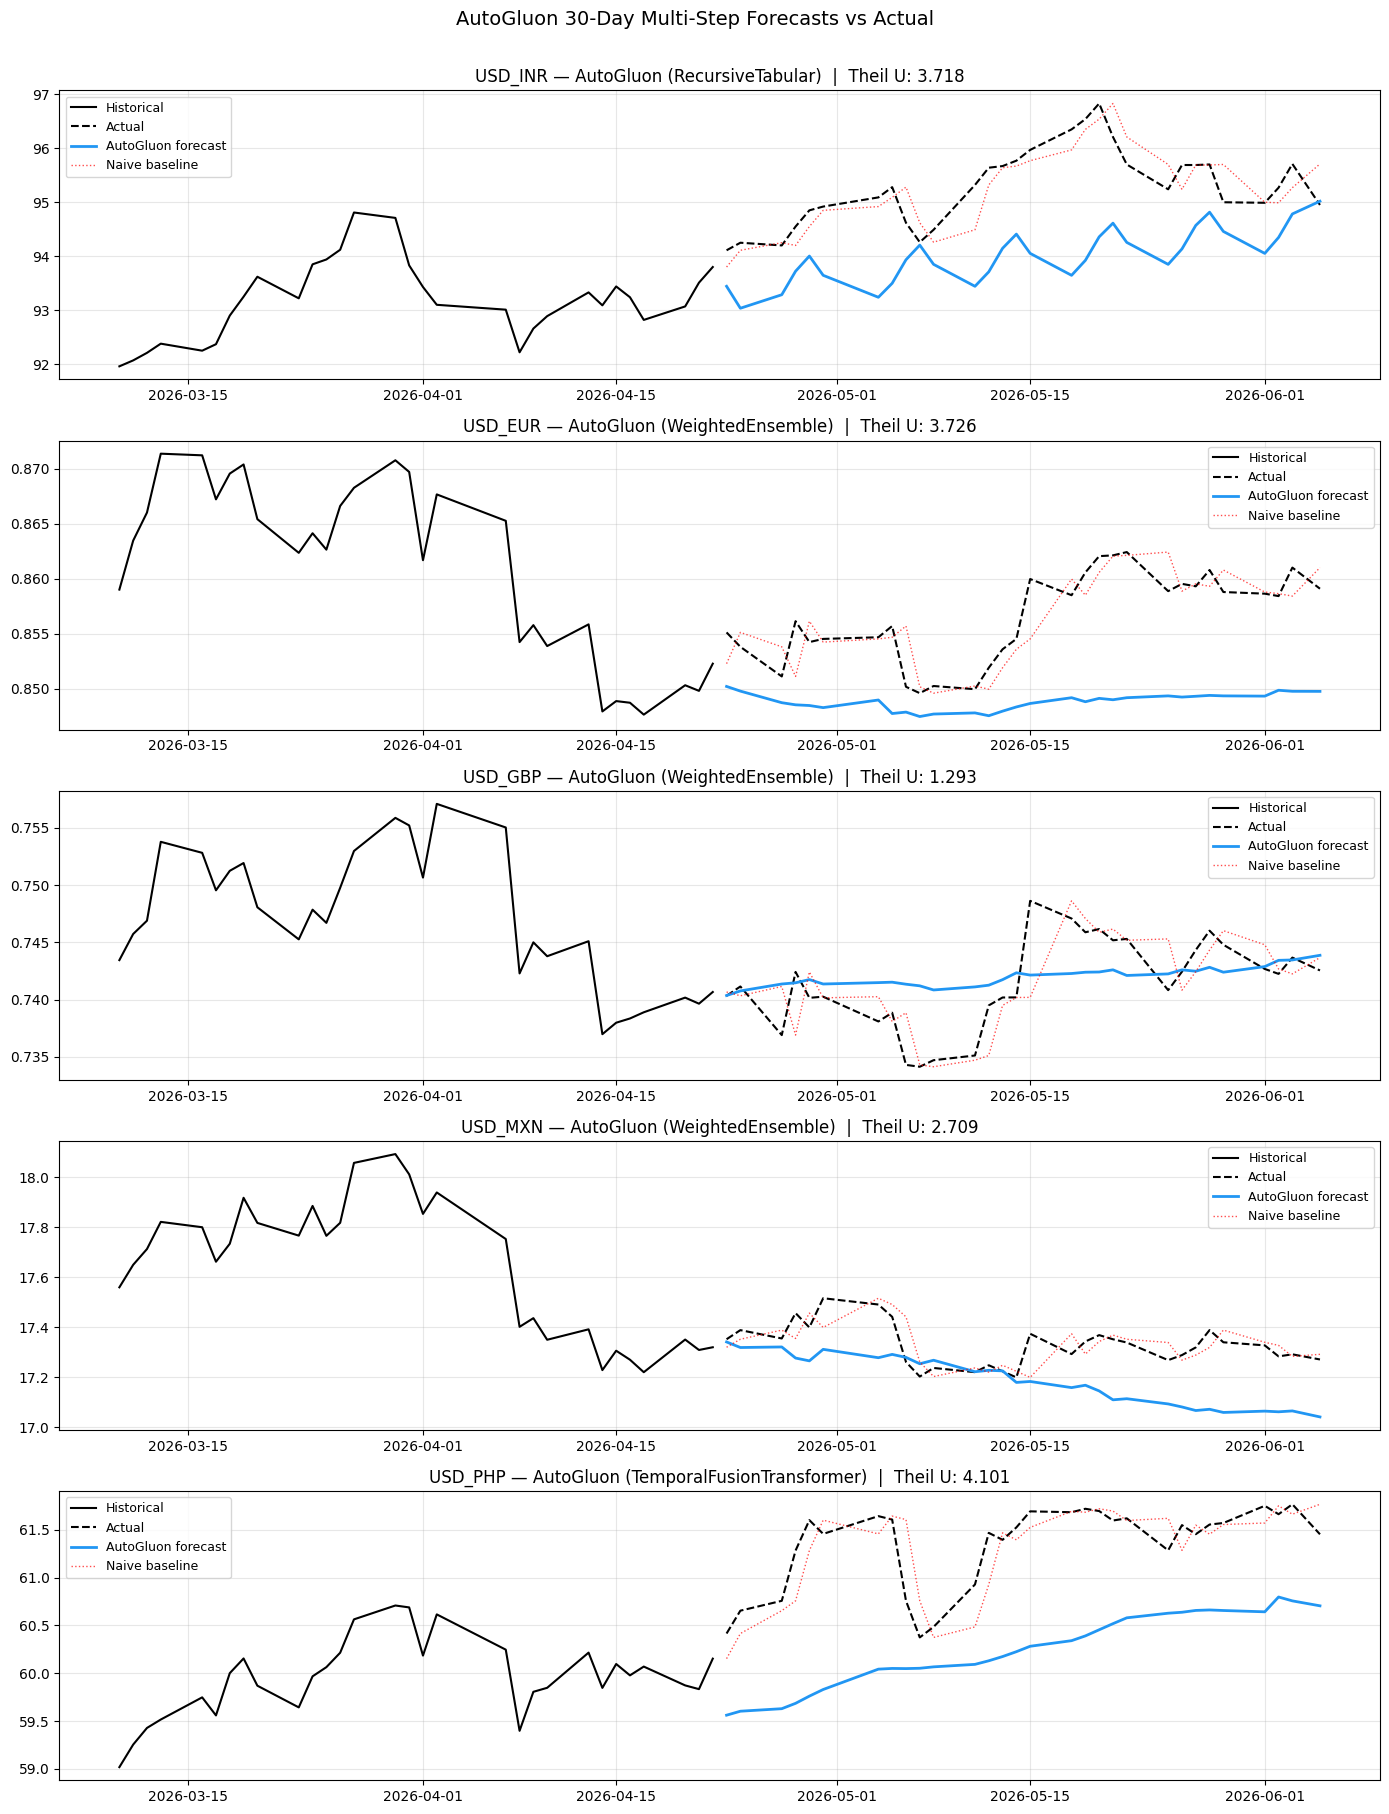

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']):
    if col in autogluon_evaluation:
        r = autogluon_evaluation[col]
        
        # Plot last 60 days of history for context
        history = ag_dataframes[col].set_index('timestamp')['target'].iloc[-60:-30]
        
        axes[i].plot(history.index, history.values, color='black', 
                     linewidth=1.5, label='Historical')
        axes[i].plot(r['date'], r['actual'], color='black', 
                     linewidth=1.5, linestyle='--', label='Actual')
        axes[i].plot(r['date'], r['forecast'], color='#2196F3', 
                     linewidth=2, label='AutoGluon forecast')
        axes[i].plot(r['date'], r['naive'], color='red', 
                     linewidth=1, linestyle=':', alpha=0.7, label='Naive baseline')
        
        theil = ((r['forecast_error']**2).mean()**0.5) / ((r['naive_error']**2).mean()**0.5)
        best = autogluon_best_models.get(col, 'unknown')
        
        axes[i].set_title(f'{col.upper()} — AutoGluon ({best})  |  Theil U: {theil:.3f}', fontsize=12)
        axes[i].legend(loc='best', fontsize=9)
        axes[i].grid(True, alpha=0.3)

plt.suptitle('AutoGluon 30-Day Multi-Step Forecasts vs Actual', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig('autogluon_forecasts_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
autogluon_output = {}

for col, result in autogluon_evaluation.items():
    if len(result) == 0:
        continue
    
    rmse = (result['forecast_error']**2).mean()**0.5
    naive_rmse = (result['naive_error']**2).mean()**0.5
    
    autogluon_output[col] = {
        'model': autogluon_best_models.get(col, 'unknown'),
        'evaluation_mode': 'multi_step_30day',
        'test_days': len(result),
        'rmse': float(rmse),
        'naive_rmse': float(naive_rmse),
        'theil_u': float(rmse / naive_rmse),
        'mape_pct': float((result['forecast_error'] / result['actual']).mean() * 100),
        'direction_accuracy': float((result['actual_direction'] == result['forecast_direction']).mean()),
        'predicted_up_rate': float((result['forecast_direction'] == 1).mean()),
        'actual_up_rate': float((result['actual_direction'] == 1).mean())
    }

with open('autogluon_results.json', 'w') as f:
    json.dump(autogluon_output, f, indent=2)

print("AutoGluon results saved to autogluon_results.json")
print("\nReady for notebook 10 — conditional evaluation")

AutoGluon results saved to autogluon_results.json

Ready for notebook 10 — conditional evaluation
